# Nonlinear ROM Demo via Kratos' Future suite

Authors: Nicolás Sibuet, Riccardo Rossi

In [1]:
!pip install KratosMultiphysics
!pip install KratosStructuralMechanicsApplication
# Automatically import additional files from KratosMultiphysics Examples repository
!wget https://raw.githubusercontent.com/KratosMultiphysics/Examples/refs/heads/master/rom_application/RomTutorialViaFutureAndTensorAdaptors/cantilever.mdpa
!wget https://raw.githubusercontent.com/KratosMultiphysics/Examples/refs/heads/master/rom_application/RomTutorialViaFutureAndTensorAdaptors/loads_and_constraints.json
!wget https://raw.githubusercontent.com/KratosMultiphysics/Examples/refs/heads/master/rom_application/RomTutorialViaFutureAndTensorAdaptors/materials.json


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.8/34.8 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import scipy.sparse as sp

import torch
import torch.nn as nn
import numpy as np

import KratosMultiphysics as KM
import KratosMultiphysics.StructuralMechanicsApplication as SMA
from KratosMultiphysics.process_factory import KratosProcessFactory
from KratosMultiphysics import scipy_conversion_tools

torch.set_default_dtype(torch.float64)

from google.colab import output
output.enable_custom_widget_manager()

## Structural problem definition

We work on a static, linear structural problem defined by a cantilever attached on its left side and with a downwards line load applied on the whole superior edge.

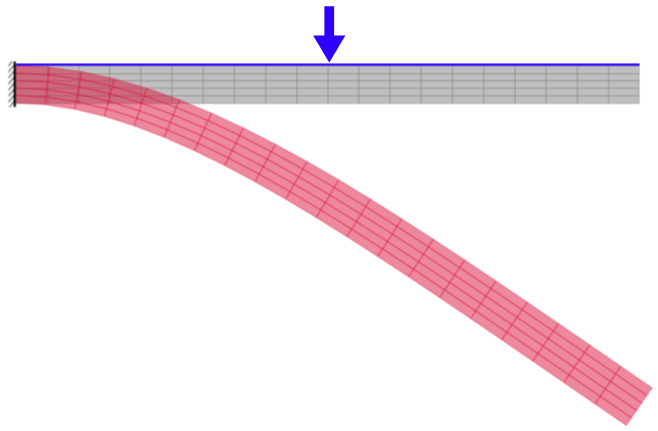

Note: You could easily repurpose the code for other cases, but beware that changes may be required.

We will use KratosMultiphysics as our numerical simulation software. To setup the problem there, we define a model and a model part using the geometry, loads, conditions and material parameters specified in the corresponding external files.

In [6]:
# Generate a modelpart and give it the geometry and DoFs info
model = KM.Model()
model_part = model.CreateModelPart("MainModelPart")

model_part.AddNodalSolutionStepVariable(KM.DISPLACEMENT)
model_part.AddNodalSolutionStepVariable(KM.REACTION)

mdpa_file_base_name = "cantilever"
model_part_io = KM.ModelPartIO(mdpa_file_base_name)
model_part_io.ReadModelPart(model_part)

KM.VariableUtils().AddDof(KM.DISPLACEMENT_X, KM.REACTION_X, model_part)
KM.VariableUtils().AddDof(KM.DISPLACEMENT_Y, KM.REACTION_Y, model_part)

# Instantiate the processes for the loads and constraints
factory = KratosProcessFactory(model)
with open("loads_and_constraints.json", 'r') as file:
    process_parameters = KM.Parameters(file.read())
list_of_processes = []
list_of_processes += factory.ConstructListOfProcesses(process_parameters["constraints_process_list"])
list_of_processes += factory.ConstructListOfProcesses(process_parameters["loads_process_list"])

# Execute them. In this case all initializations can be done at once as loads are costant
for process in list_of_processes:
    process.ExecuteInitialize()
    process.ExecuteBeforeSolutionLoop()
    process.ExecuteInitializeSolutionStep()

# Apply material parameters specified in materials.json
with open("materials.json", 'r') as material_file:
    material_parameters = KM.Parameters(material_file.read())
KM.ReadMaterialsUtility(model).ReadMaterials(material_parameters)

## Kratos Helper class

$\newcommand{\Res}{\mathbf{R}}$
$\newcommand{\uvec}{\mathbf{u}}$
$\newcommand{\qvec}{\mathbf{q}}$
$\newcommand{\Fext}{\mathbf{F}_{ext}}$
$\newcommand{\Dec}{\mathbf{D}(\qvec)}$
$\newcommand{\DecGrad}{\frac{\partial \Dec}{\partial \qvec}}$
$\newcommand{\DecGradT}{\left(\DecGrad\right)^T}$
$\newcommand{\zerovec}{\boldsymbol{0}}$
$\newcommand{\dimof}[1]{\text{dim}#1}$

Next up, we create a Python class that will use KratosMultiphysics to process this case by building the system:

$$ K \Delta\uvec = \Res(\uvec) $$

where:
* $\uvec$ is the vector containing the currently applied displacements of each node (in $x$ and $y$ directions) with respect to the undeformed shape of the cantilever.
* $\Delta \uvec$ is the increment of displacements that would solve the system.
* $K$ is the system's stiffness matrix, which is constant for linear problems.
* $\Res(\uvec)$ is the current residual vector, which corresponds to $\Fext - K\uvec$ with $\Fext$ the vector of external loads.

Specifically, we implement three main methods that either generate or use these quantities:

* Given an arbitrary vector $\uvec$, return the corresponding residual vector $\Res$ and stiffness matrix $K$.
* Perform the Full Order Model simulation by solving the linear system with the displacements initilized at zero.
* Get the squared norm of the residual and the potential energy of the system at a given $\uvec$. We will use them as metrics later on.

In [90]:
class KratosHelper():

    # Parameters for the Kratos scheme
    scheme_parameters = KM.Parameters("""{
        "build_settings": {
            "name": "block_builder"
        },
        "echo_level": 0,
        "move_mesh": false,
        "name": "static_scheme",
        "reform_dofs_at_each_step": false
        }""")

    def __init__(self, model, model_part):

        self.model = model
        self.model_part = model_part

        # Instantiate and initialize Kratos static scheme and strategy data
        self.scheme = KM.Future.StaticScheme(self.model_part, self.scheme_parameters)
        self.strategy_data = KM.Future.ImplicitStrategyData()

        self.scheme.Initialize(self.strategy_data)
        self.scheme.InitializeSolutionStep(self.strategy_data)
        self.scheme.InitializeNonLinIteration(self.strategy_data)

        # Get a TensorAdaptor for the initial node positions. The data can be retrieved later via CollectData()
        dim=2
        self.node_pos_ta = KM.TensorAdaptors.NodePositionTensorAdaptor(self.model_part.Nodes, KM.Configuration.Initial, data_shape = [dim])
        self.node_pos_ta.Check()

        # Get number of DoFs for later use
        self.num_dofs = len(self.strategy_data.GetEffectiveDofSet())

    def assign_values_to_kratos_database(self, u_vec):
        # Assigns displacement values directly to the Kratos DoFs, ensuring correct order.
        self.strategy_data.GetEffectiveDofSet().SetValues(u_vec.ravel())

    def build_system_to_u(self, u_vec, as_scipy=False):
        # Set all system vectors/matrices to zero
        lin_system = self.strategy_data.GetLinearSystem()
        lin_system.GetVector(KM.Future.DenseVectorTag.Dx).SetValue(0.0)
        rhs = lin_system.GetVector(KM.Future.DenseVectorTag.RHS)
        lhs = lin_system.GetMatrix(KM.Future.SparseMatrixTag.LHS)
        rhs.SetValue(0.0)
        lhs.SetValue(0.0)

        # Assign given u_vec to the Kratos database
        self.assign_values_to_kratos_database(u_vec.ravel())

        # Build the system and apply Dirichlet conditions
        self.scheme.Build(lhs, rhs)
        self.scheme.BuildLinearSystemConstraints(self.strategy_data)
        self.scheme.ApplyLinearSystemConstraints(self.strategy_data)

        # Collect built Kratos' RHS and LHS with constraints applied
        eff_lin_sys = self.strategy_data.GetEffectiveLinearSystem()
        eff_rhs = eff_lin_sys.GetVector(KM.Future.DenseVectorTag.RHS)
        eff_lhs = eff_lin_sys.GetMatrix(KM.Future.SparseMatrixTag.LHS)

        # If as_scipy, convert rhs to numpy and lhs to scipy csr martix
        if as_scipy:
            eff_rhs = np.array(eff_rhs, copy=False)
            eff_lhs = scipy_conversion_tools.to_csr(eff_lhs)

        return eff_rhs, eff_lhs

    def get_node_coordinates(self):
        # Use CollectData() for the TensorAdaptor instantiated previously to collect Kratos' data.
        # Then .data returns these values as a numpy array.
        self.node_pos_ta.CollectData()
        return self.node_pos_ta.data

    def perform_FOM_simulation(self):
        # Sets system to 0 (undeformed configuration), then builds it.
        self.build_system_to_u(np.zeros(self.num_dofs))

        # Instantiate a linear solver, then solve the system
        solver = KM.Future.SkylineLUFactorizationSolver()
        eff_lin_sys = self.strategy_data.GetEffectiveLinearSystem()
        solver.PerformSolutionStep(eff_lin_sys)
        solver.FinalizeSolutionStep(eff_lin_sys)

        # Get the resulting displacements vector as our result
        eff_dx = eff_lin_sys.GetVector(KM.Future.DenseVectorTag.Dx)

        # print("HEREEEEEE", np.linalg.norm(self.build_system_to_u(np.array(eff_dx, copy=False), as_scipy=True)[0])**2)
        # print()

        return np.array(eff_dx, copy=True)

    def get_r_norm_squared_and_potential_energy_at_u(self, u_vec):
        R, K = self.build_system_to_u(u_vec)
        r_norm_squared = np.linalg.norm(R)**2
        potential_energy = -np.dot(u_vec,R)-1/2*np.dot(u_vec,K@u_vec)
        return r_norm_squared, potential_energy

kratos_helper = KratosHelper(model, model_part)


## Decoder definition in Pytorch

As of now, we have no way of defining arbitrary displacement vectors $\uvec$ other than manually creating an array with each individual displacement.

Let's say that we would like to generate candidates of this displacement by controlling at most 10 variables. We could define a function that will apply these user-controllable variables onto the coordinates of each node's undeformed position $(x_i, y_i)$ to obtain the new deformation.

We will name this function as **decoder** $\Dec$, which has the same shape as $\uvec$. The input $\qvec$ is the vector holding the control variables that we define for our function.

We may use any function like for our decoder, but ideally we should find one that can approximate the real behaviour of the cantilever. Something important to take into account are the Dirichlet conditions: the nodes at the left edge of the cantilever have their displacement fixed to 0 in the simulation. Therefeore, our functions should always be $0$ at $x_i=0$.

The next code block defines the class CantileverParametrization, which will work as our decoder. It is implemented in Pytorch so that we can automatically get the jacobian of $\Dec$ with respect to $\qvec$, which we will use in future sections.

We implement the decoder with the functions (for node $i$):
$$D_{i,x} = x_i*(a*y_i + b)$$
$$D_{i,y} = x_i*(c*x_i^3+d*x_i^2+e*x_i+f)$$

With $\qvec = (a, b, c, d, e, f)^T$

> **Try yourself**: Find other functions that look realistic for this scenario. You will find sections in the next code block marked by a comment saying "MODIFIABLE CODE". Those will have the instructions on what to change. Suggested functions to try are:
$$ D_{i,x} = x_i (\sin(x_i a+b)+y_i c),\quad D_{i,y} = x_i \sin(x d+e)$$
$$ D_{i,x} = x_i (a x_i y_i+b y_i+c),\quad D_{i,y} = x_i (d x_i^3+e x_i^2+f x_i+g)$$




In [91]:
class CantileverParametrization(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize tensors for x and y coordinates from the kratos interface (this is constant)
        self.coords_tensor = torch.tensor(kratos_helper.get_node_coordinates(), dtype=torch.float64)

        ##### MODIFIABLE CODE

        # Adjust the number of parameters you need for your model (see the forward method for more info)
        num_params = 6

        #####

        # Initialize parameters to zero
        self.init_params = torch.tensor(np.zeros(num_params), dtype=torch.float64)


    def get_coords(self):
        return self.coords_tensor[:,0], self.coords_tensor[:,1]

    def forward(self, q_tens):
        x,y = self.get_coords()

        ##### MODIFIABLE CODE

        # Here we assume that num_params is six. Change accordingly
        a,b,c,d,e,f = q_tens

        # Define the parametrized functions for the displacement on x and on y
        D_x = x*(a*y+b)
        D_y = x*(c*x**3+d*x**2+e*x+f)

        #####

        return torch.vstack([D_x, D_y]).T.ravel()

    def run(self, q):
        # Ensure q is a tensor before passing to forward
        if not isinstance(q, torch.Tensor):
            q = torch.tensor(q, dtype=torch.float64)
        return self.forward(q).detach().numpy()

    def get_jacobian(self, q):

        # Get the function to compute the jacobian of the decoder with respect to q (unevaluated)
        self.compute_jacobian_function = torch.func.jacfwd(self.forward)

        if not isinstance(q, torch.Tensor):
            q = torch.tensor(q, dtype=torch.float64)
        return self.compute_jacobian_function(q).detach().numpy()

decoder = CantileverParametrization()

### Interactive decoder plot



To better understand the meaning of the decoder and its behaviour for a particular parametrization, we provide an interactive plot.
It allows the user to manually adjust the decoder input variables ($\qvec$) individually and compare the undeformed cantilever mesh against the one given by the decoder in real time.

We will use the result of the decoder as the displacement vector $\uvec$ to apply within the KratosHelper class. That way, we can compute $||\Res(\Dec)||_2^2$ and the potential energy $U(\Dec)$ for the displayed configuration.

First, we instantiate a class that will manage the plotting of the cantilever.

In [92]:
# @title
from IPython.display import Markdown, display

display(Markdown("""
### `Plotter Class` (code not to be studied)
Uses Matplotlib's pyplot and PolyCollections to plot the cantilever's mesh according to given displacement vectors.

<br>

**Instantiate via:**

        Plotter(model_part, kratos_helper, decoder)

**Main methods:**
  * plot_meshes(u_list, labels = None, title = None, colors = None)

    Plots one or multiple configurations of the cantilever mesh
    * u_list: list of displacements vectors (numpy arrays) to plot
    * labels: list of string labels for the legend
    * title: title for the figure
    * colors: list of color names to use for each configuration (otherwise automatically assigned)
"""))


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import PolyCollection

class Plotter():
    def __init__(self, model_part, kratos_helper, decoder):

        # Get connectivity from model part (nodes for each quad element)
        node_id_to_idx = {node.Id: i for i, node in enumerate(model_part.Nodes)}
        self.connectivity = np.array([[node_id_to_idx[node.Id] for node in elem.GetGeometry()] for elem in model_part.Elements])

        self.kratos_helper = kratos_helper
        self.decoder = decoder

        self.u_fom = None

    def get_positions_from_displacement(self, u):
        coords = self.kratos_helper.get_node_coordinates()
        return u.reshape(coords.shape) + coords

    def plot_meshes(self, u_list, labels = None, title = None, colors = None):
        # Create a list even if there is only one mesh to simulate
        if type(u_list) is not list:
            u_list = [u_list]
        if labels is not None and type(labels) is not list:
            labels = [labels]
        if colors is None:
            # Get a set of colors from a predefined palette (max 10 different colors)
            colors = plt.get_cmap('tab10').colors[:len(u_list)]
        elif type(colors) is not list:
            colors = [colors]

        # Single axis for all meshes
        fig, ax = plt.subplots(figsize=(10, 6))

        # Get node positions from fiven displacements
        pos_vec_list = [self.get_positions_from_displacement(u)for u in u_list]

        # Get positions for each element vertex
        element_verts_list = [pos_vec[self.connectivity] for pos_vec in pos_vec_list]

        # Obtain and add mesh visualization objects for all meshes.
        # First mesh will appear at the back, then each one in front of the previous one.
        for element_verts, color in zip(element_verts_list, colors):
            mesh_object = PolyCollection(element_verts, color = color, linewidths=0.8, alpha=0.5)
            ax.add_collection(mesh_object)

        # Automatically adjust limits with a margin
        # Combine all points to find the global bounding box
        all_points = np.vstack(pos_vec_list)
        ax.update_datalim(all_points)  # Tell the axis about the data extent
        ax.margins(0.05)               # Add a 5% margin around the data
        ax.autoscale_view()            # Apply the limits

        ax.set_aspect('equal', 'box')  # Forces 1:1 aspect ratio

        if title is not None: ax.set_title(title)
        if labels is not None:
            custom_lines = [Line2D([0], [0], color=color, lw=1.5, alpha=0.5) for color in colors]
            ax.legend(custom_lines, labels, loc='best')

        plt.tight_layout()
        plt.show()


### `Plotter Class` (code not to be studied)
Uses Matplotlib's pyplot and PolyCollections to plot the cantilever's mesh according to given displacement vectors.

<br>

**Instantiate via:**

        Plotter(model_part, kratos_helper, decoder)

**Main methods:**
  * plot_meshes(u_list, labels = None, title = None, colors = None)

    Plots one or multiple configurations of the cantilever mesh
    * u_list: list of displacements vectors (numpy arrays) to plot
    * labels: list of string labels for the legend
    * title: title for the figure
    * colors: list of color names to use for each configuration (otherwise automatically assigned)


In [93]:
plotter = Plotter(model_part, kratos_helper, decoder)

Then we define a function that will make use of the plotter to draw both the undeformed cantilever and the cantilever with the deformation given by the decoder at a given $\qvec$ and print the metrics mentioned earlier.

In [94]:
def updatable_plot_function(q):
    # Run decoder
    u = decoder.run(q)

    plotter.plot_meshes([undeformed_u, u], title = "Decoder solution given q", colors = ["grey", "crimson"], labels=["Undeformed", "Decoder solution"])

    # Print current q vector
    print('Current q:', q)
    print()

    # Print residual norm squared and potential energy
    R2, Pi = kratos_helper.get_r_norm_squared_and_potential_energy_at_u(u)
    print("|R|^2: ", R2)
    print("Potential energy: ", Pi)

The function above is called at every update of the following interactive widget.

Now you can play around with the values of $\qvec$ and observe.

In [95]:
# @title
from IPython.display import Markdown, display

display(Markdown("""
### `Interactive widget` (code not to be studied)
"""))

import ipywidgets as widgets
from IPython.display import display

# Obtain parameter count and names.
param_names = [f"q_{i}" for i in range(len(decoder.init_params))]
param_multipliers_names = [f"Multiplier for q_{i}" for i in range(len(decoder.init_params))]

# Create a dictionary of sliders
sliders = {
    name: widgets.FloatSlider(
        value=0.0,
        min=-10.0,
        max=10.0,
        step=0.5,
        description=f"{name}:",
        continuous_update=True  # Only updates on release to prevent lag
    )
    for name in param_names
}
multiplier_sliders = {
    name: widgets.FloatSlider(
        value=0.0,
        min=-5.0,
        max=5.0,
        step=1,
        description=f"x10^()",
        continuous_update=False  # Only updates on release to prevent lag
    )
    for name in param_multipliers_names
}
sliders.update(multiplier_sliders)

undeformed_u = np.zeros(kratos_helper.num_dofs)

# 3. Dynamic callback using **kwargs
def update_view(**kwargs):
    # Reconstruct the vector q in the correct order
    q = [kwargs[name]*10**kwargs[mult_name] for name, mult_name in zip(param_names,param_multipliers_names)]

    updatable_plot_function(q)

# 4. Link all dynamic sliders via dictionary unpacking
out = widgets.interactive_output(update_view, sliders)

# 5. Arrange dynamically into a 2-column grid layout
ordered_sliders_list = []
for name, mult_name in zip(param_names, param_multipliers_names):
    ordered_sliders_list.extend([sliders[name], sliders[mult_name]])
ui = widgets.GridBox(
    ordered_sliders_list,
    layout=widgets.Layout(grid_template_columns="repeat(2, 350px)")
)

display(ui, out)


### `Interactive widget` (code not to be studied)


GridBox(children=(FloatSlider(value=0.0, description='q_0:', max=10.0, min=-10.0, step=0.5), FloatSlider(value…

Output()

## ROM solution via Newton Raphson optimization

### FOM reminder:

In the Full Order Model, we build a residual vector $\mathbf{R}(\uvec) = \Fext - K\uvec$. Then, we obtain the value of u at root ($\Res(\uvec)=\zerovec$) via a linear solver.

This means solving a linear algebra problem with as many unknowns as Degrees of Freedom. In this case we have displacement in two directions for 126 nodes, therefore 252 DoFs (12 of them are fixed by Dirichlet conditions)

Note: in non-linear problems, the stiffness matrix $K$ would depend on the displacements too ($K(\uvec)$), and the root of $\Res(\uvec)$ would be found via iterative solvers like Newton Raphson.

### ROM's goal:

Imagine that 252 DoFs is too much for us, and we want to reduce it to something of the order of 10. In a real engineering problem, we could be talking about milions of DoFs for the FOM and around 100 ideally for the ROM.

That is where our previously-created decoder comes in, defining the operation $\uvec = \Dec$. By limiting the kinematics of our cantilever (limiting the possibilities of its deformation $\uvec$ via user-defined functions) in an appropriate, informed way, we can transform the FOM problem into one that optimizes the input of our decoder ($\qvec$), instead of every node's displacement individually. Therefore we will end up with a problem that has as many DoFs as the length of our $\qvec$ vector (6 in the original decoder definition from the notebook).

How do we achieve this reduction?

We start by substituting $\uvec$ by $\Dec$ in the residual expression:
$$\Res(\Dec) = \Fext - K\Dec$$
The problem now is overdetermined (252 equations for 6 unknowns). Therefore, most probably, there will be no exact solution. (Think of it like this: if the decoder that we implemented is not capable of representing the FOM solution exactly, it will be mathematically impossible to get $\Res(\qvec)=\zerovec$).

To make our problem determined, what we look for is the value of $\Res(q)$ that is orthogonal to an appropriate (reduced) test space. That is, we need to solve:

$$ \Psi(\qvec)^T K\Dec = \Psi(\qvec)^T \Fext$$

with $\Psi(\qvec)$ a projection matrix (full rank) of dimensions $\dimof(\uvec) \times \dimof(\qvec)$, so we end up with a determined system of $\dimof(\qvec)$ equations and $\dimof(\qvec)$ unknowns. The obtained $\Res$ is the one that is orthogonal to the column space of $\Psi(\qvec)$.

### ROM's test space choice

What would be a good choice for $\Psi(\qvec)$? We will study two different options:

* **Galerkin projection**:

  In the Galerkin projection we use simply:
  
  $$\Psi(\qvec) = \DecGrad$$

  This yields the determined system:
  
  $$\DecGradT K \Dec = \DecGradT \Fext$$

  However, Galerkin projection not suitable for non-symmetric systems (like advection-dominated fluid flows).

> **Note**: In the specific case of structural problems with symmetric positive definite $K$, finding the solution to the Galerkin problem is equivalent to minimizing the potential energy of the constrained system:
$$U(\uvec)=\frac{1}{2}\uvec^T K \uvec-\uvec^T\Fext$$
$$⇒ U(\qvec)=\frac{1}{2}\Dec^T K \Dec-\Dec^T\Fext$$
To minimize, we find the root of the gradient:
$$\frac{\partial U(\qvec)}{\partial \qvec} = \frac{1}{2}\left(\frac{\partial \Dec}{\partial \qvec}\right)^T (K + K^T) \Dec-\left(\frac{\partial \Dec}{\partial \qvec}\right)^T\Fext = 0$$
$K$ symmetric, therefore: $\left(\frac{\partial \Dec}{\partial \qvec}\right)^T K \Dec = \left(\frac{\partial \Dec}{\partial \qvec}\right)^T\Fext$

* **Least-Squares Petrov-Galerkin (LSPG) projection**:

  In this one, we use:

  $$\Psi(\qvec) = K \DecGrad$$

  This yields the determined system:
  
  $$\DecGradT K^T K \Dec = \DecGradT K^T \Fext$$

  The solution of the LSPG problem should be a physically sound choice in all cases, however the problem might be ill-conditioned (high condition number from $K^T K$), making it difficult to solve.

> **Note**: Solving the LSPG problem is equivalent to minimizing the squared norm $||\Res||_2^2$ (that is why it is physically reasonable for all simulations).
This minimization is equivalent to finding the root of the gradient:
$$\frac{\partial ||\Res(\qvec)||_2^2}{\partial \qvec} = 2\left(\frac{\partial \Res(\qvec)}{\partial \qvec}\right)^T \Res(\qvec)=2\left(-K\DecGrad\right)^T(\Fext-K\Dec)=\zerovec$$

One might define any other arbitrary test space onto which to reduce the overdetermined problem. That is, any arbitrary $\Psi(\qvec)$. In that case we would be talking about a **Petrov-Galerkin projection**. We will not go more in-depth about it.

### Solving the ROM system:

Now that we have a determined system we are just faced with the problem of it being  (potentially) nonlinear. Therefore we should use Newton Raphson ...

Arrive to $K_{ROM}\qvec=\F_{ROM}$

The next code computes the ROM solution given our decoder. Both Galerkin and LSPG projections are available to choose from.

Once the ROM solution is computed, we plot it and compare it against the FOM one to see how good it is in terms of displacement. We also compute some metrics to compare.

> **Note**: As it is, for a linear decoder the iterator marks 2 iterations instead of one. That is because the tolerance condition to stop the solver is relative, so it needs a first iteration for reference. You can check that, in linear cases, the result of those two iterations will be virtually the same.

Starting solver. Using galerkin projection.
Iteration 1:
  q: tensor([ 6.8814e+00, -1.1372e-15, -1.4116e-09,  3.1534e-10, -3.4241e+00,
        -3.3333e-03])
 |dq|/|q|: 1.0
Iteration 2:
  q: tensor([ 6.8814e+00,  3.4899e-18,  2.6465e-12, -4.7828e-13, -3.4241e+00,
        -3.3333e-03])
 |dq|/|q|: 1.9050709590653461e-10
Converged in 2 iterations.


/tmp/ipykernel_603/3041058972.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  q = q + dq


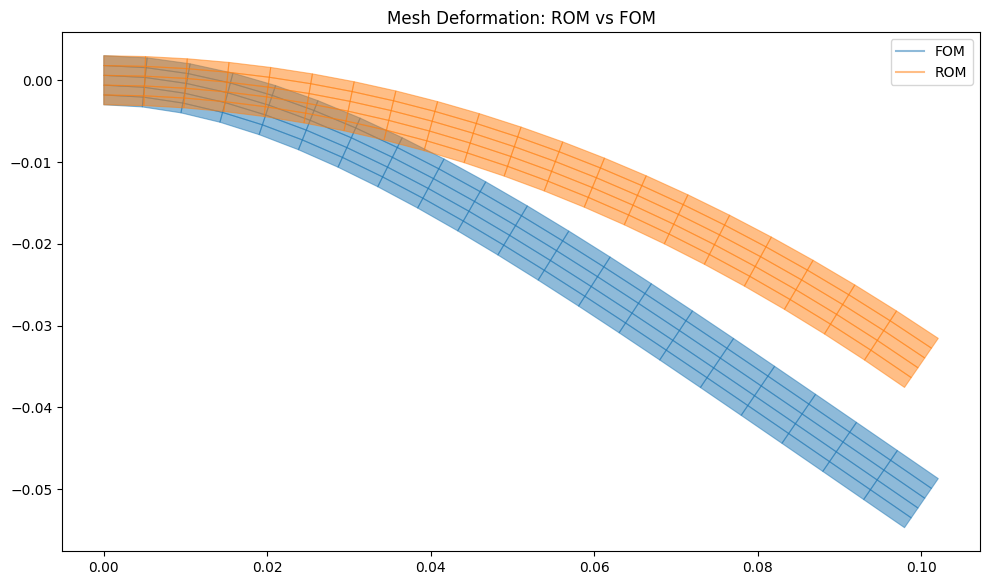

ROM |R|^2:  19869368.425917372
ROM Potential energy:  -5.7972250860453745
FOM |R|^2:  9.697628654688252e-16
FOM Potential energy:  -10.369603356033636


In [98]:
##### MODIFIABLE CODE
projection = "galerkin"   # Choose between "galerkin" and "lspg"
#####

# Get the pytorch tensor for the initial parameters vector
q = decoder.init_params

# Newton Raphson loop
it = 0
it_max = 10
converged=False
print(f"Starting solver. Using {projection} projection.")
while it<it_max and not converged:
    it+=1

    #u = D(q)
    u = decoder.run(q)

    #compute Kfom(u=D(q)), Rfom(u=D(q))
    R, K = kratos_helper.build_system_to_u(u, as_scipy=True)

    #compute GradD:= diff(D(q),q)
    grad_D = decoder.get_jacobian(q)

    #define and solve ROM problem
    if projection == "galerkin":
        K_rom = grad_D.T@K@grad_D
        R_rom = grad_D.T@R
    elif projection == "lspg":
        K_rom = grad_D.T@K.T@K@grad_D
        R_rom = grad_D.T@K.T@R
    dq = np.linalg.solve(K_rom,R_rom)

    #update database
    q = q + dq

    #check convergence
    ratio = np.linalg.norm(dq)/np.linalg.norm(q)

    print(f"Iteration {it}:")
    print("  q:", q)
    print(" |dq|/|q|:", ratio)

    if ratio < 1e-9:
        converged = True
        print(f"Converged in {it} iterations.")

# Plot the ROM results against the FOM ones.

u_fom = kratos_helper.perform_FOM_simulation()
u_rom = decoder.run(q)

plotter.plot_meshes([u_fom, u_rom], labels = ["FOM", "ROM"], title = "Mesh Deformation: ROM vs FOM")

# Print residual norm squared and potential energy
R2_rom, Pi_rom = kratos_helper.get_r_norm_squared_and_potential_energy_at_u(u_rom)
print("ROM |R|^2: ", R2_rom)
print("ROM Potential energy: ", Pi_rom)
R2_fom, Pi_fom = kratos_helper.get_r_norm_squared_and_potential_energy_at_u(u_fom)
print("FOM |R|^2: ", R2_fom)
print("FOM Potential energy: ", Pi_fom)


By comparing the visualizations, squared norm of residual and potential energy of the Galerkin case and the LSPG case one may derive interesting insights.